# Linear Regression Model

Linear regression is a fundamental statistical and machine learning technique used to model the relationship between a dependent variable and one or more independent variables. It is a type of supervised learning algorithm that learns from labeled data to predict continuous outcomes.

## About Data
This is a simple dataset to start with. It contains only the height (inches) and weights (pounds) of 25,000 different humans of 18 years of age. This dataset can be used to build a model that can predict the heights or weights of a human.

### source:
    https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset
    

#### Acknowledgement:
Link: http://socr.ucla.edu/docs/resources/SOCR_Data/SOCR_Data_Dinov_020108_HeightsWeights.html
Scraped the aforementioned HTML page using a Regex Parser. (BeautifulSoup - Python)



## 1. Importing Python Libraries

In [16]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



## 2. Load Data

In [17]:
df = pd.read_csv("SOCR-HeightWeight.csv")

## 3. Perform Basic EDA

### 3.1 Shape

In [18]:
df.shape

(25000, 3)

### 3.2 Column Names & Data Types

In [19]:
df.dtypes

Index               int64
Height(Inches)    float64
Weight(Pounds)    float64
dtype: object

### 3.3 check Top 10 Rows

In [20]:
df.head(10)

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
5,6,68.69784,123.3024
6,7,69.80204,141.4947
7,8,70.01472,136.4623
8,9,67.90265,112.3723
9,10,66.78236,120.6672


### 3.4 Drop "Index" Column

In [21]:
df = df.drop("Index",axis=1)

### 3.5 Renaming Columns to easier notations

In [22]:
df = df.rename(columns={"Height(Inches)": "height_inch"})
df = df.rename(columns={"Weight(Pounds)": "weight_lb"})

### 3.6 seprating Numeric Columns


In [23]:
height = df[['height_inch']]
weight = df['weight_lb']

### 3.7 overview Data

In [24]:
df.describe()

,height_inch,weight_lb
count,25000.000000,25000.000000
mean,67.993114,127.079421
std,1.901679,11.660898
min,60.278360,78.014760
25%,66.704397,119.308675
50%,67.995700,127.157750
75%,69.272958,134.892850
max,75.152800,170.924000


### 3.8 Missing Values

In [25]:
df.isnull().sum()

height_inch    0
weight_lb      0
dtype: int64

### 3.9 Duplicate values

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.duplicated().sum()

np.int64(0)

## 4. Split Test and Train Data 

In [28]:
height_train , height_test ,weight_train , weight_test = train_test_split(height,weight,test_size=0.3,random_state=0)

## 5. Create & Fit modle object

In [29]:
model = LinearRegression()
model = model.fit(height_train,weight_train)

## 6. Check Modle Fitness

### 5.1 Overview by graph

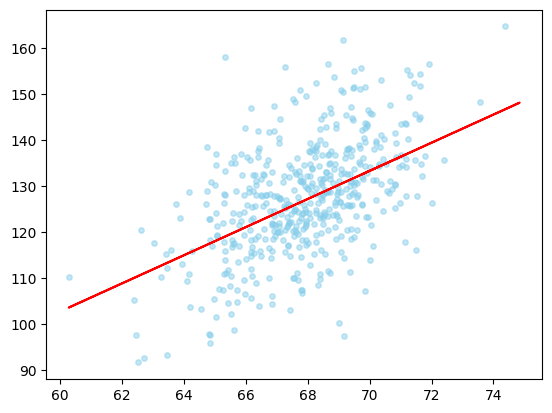

In [ ]:
sample = 500

plt.scatter(
    height_train[0:sample],
    weight_train[0:sample],
    color='skyblue',
    s=15,
    alpha=0.5
)

plt.plot(height_train, model.predict(height_train), color='red')

plt.show()

### 6.2 Check Fitness Score

#### for Testing data:

In [31]:
model.score(height_test,weight_test)

0.2537860641652152

#### for Training Data

In [32]:
model.score(height_train,weight_train)

0.25241033931863766

### 6.3 Test on Random Value 

In [33]:
model.predict([[153]]) # always use 2D arrays here

c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([387.19760678])

In [34]:
arr = [[123],[126],[120],[180],[143]]
model.predict(arr)

c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([295.41198805, 304.59054992, 286.23342617, 469.80466364,
       356.60240054])

## 7. Final Model

In [35]:
# height = int(input("Please Enter Height in Inches : " ))
# # height = [[138]]
# weight = model.predict([[height]])
# print("The Predicted Weight in Pounds is : ",weight)